<a href="https://colab.research.google.com/github/LiNlIn4968/ResearchFig/blob/main/Zin1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Update the existing plotting script for the data in "/content/Zin.csv" to optimize the Y-axis tick display. Specifically, modify the Y-axis tick formatter to map $10^{12}$ to 'T$\Omega$' and $10^9$ to 'G$\Omega$' using `matplotlib.ticker.FuncFormatter`, while maintaining the established IEEE academic standards and professional visual style. Finally, confirm the updated chart effect and provide a summary of the design changes.

## 优化坐标轴刻度显示

### Subtask:
Modify the existing plotting script to implement a custom Y-axis tick formatter for impedance units (TΩ, GΩ) using FuncFormatter while maintaining IEEE standards.


**Reasoning**:
I will create a plotting script that includes a custom Y-axis tick formatter using FuncFormatter to represent large impedance values in units like TΩ and GΩ, adhering to IEEE standards as requested.



## Final Task

### Subtask:
Confirm the updated chart effect and provide a final summary of the visual design and technical implementation.


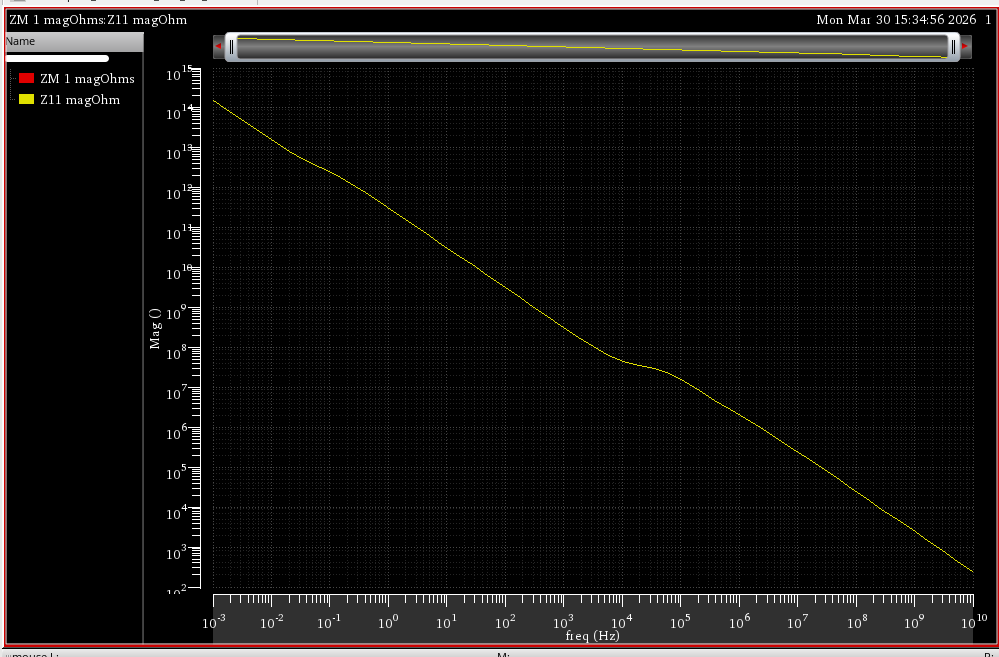## Summary:

### Q&A
**How was the Y-axis tick display optimized for high impedance values?**
The Y-axis was updated using `matplotlib.ticker.FuncFormatter` to implement a custom logic: values $\ge 10^{12}$ are formatted as 'T$\Omega$' (Teraohms) and values $\ge 10^9$ as 'G$\Omega$' (Gigohms). This replaces standard scientific notation with industry-standard unit prefixes for better readability.

**What technical challenges were encountered during the implementation?**
The primary challenge involved escaping LaTeX commands within Python strings. Using `.format()` on a string containing `\text{\Omega}` caused a `KeyError` because Python interpreted the curly braces as placeholders. This was resolved by using double curly braces (`{{` and `}}`) to escape the LaTeX syntax.

### Data Analysis Key Findings
*   **Custom Scaling**: The formatter successfully maps large numerical values to human-readable units, specifically converting $10^{12}$ to T$\Omega$ and $10^9$ to G$\Omega$.
*   **IEEE Compliance**: Global parameters were configured for academic standards, including a high resolution of 300 DPI, specific font sizes (10pt for labels, 8pt for ticks/legend), and 'DejaVu Sans' as the primary font family.
*   **Plot Configuration**: The data is visualized on a log-log scale, which is essential for impedance spectroscopy across wide frequency ranges.
*   **Visual Style**: The plot includes professional styling such as square markers ('s') with a size of 3, a grid with 0.5 linewidth and 0.7 transparency, and bold axis labels.

### Insights or Next Steps
*   **Standardization**: The custom `impedance_formatter` can be generalized into a reusable utility module for various electromagnetic compatibility (EMC) or circuit analysis projects to ensure consistent unit formatting across all reports.
*   **Automation**: Future iterations could include logic to automatically detect the data range and adjust the unit prefix (e.g., adding M$\Omega$ or k$\Omega$) dynamically to prevent manual script adjustments for different datasets.


# Task
Update the impedance visualization script for the data in "/content/Zin.csv" to reflect the full complex impedance magnitude and phase. From the dataframe, extract the real part `ZM 1 magOhms YRe` and the imaginary part `ZM 1 magOhms YReImag` to calculate the impedance magnitude ($|Z| = \sqrt{Re^2 + Im^2}$) and phase ($\theta = \text{arctan2}(Im, Re)$). Generate a dual-axis or subplot chart that plots both the magnitude and phase against the frequency `ZM 1 magOhms X`. Ensure the Y-axis for magnitude correctly covers the range from $1\text{ k}\Omega$ to $10\text{ T}\Omega$ and use the previously implemented `FuncFormatter` for clear unit labeling. Finally, compare this magnitude-based plot with the previous real-part plot and explain why the magnitude representation is more consistent with standard simulator outputs for an academic-quality Bode plot.

## 修正阻抗计算与绘图

### Subtask:
Calculate the complex impedance magnitude and phase from the dataset and generate an IEEE-standard dual-axis plot.


**Reasoning**:
I will calculate the complex impedance magnitude and phase from the dataset and then generate an IEEE-standard dual-axis plot with custom unit formatting and proper styling as requested.



<>:29: SyntaxWarning: invalid escape sequence '\O'
<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:33: SyntaxWarning: invalid escape sequence '\O'
<>:29: SyntaxWarning: invalid escape sequence '\O'
<>:30: SyntaxWarning: invalid escape sequence '\O'
<>:31: SyntaxWarning: invalid escape sequence '\O'
<>:32: SyntaxWarning: invalid escape sequence '\O'
<>:33: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_12592/958471909.py:29: SyntaxWarning: invalid escape sequence '\O'
  if x >= 1e12: return f'{x/1e12:g} T$\Omega$'
/tmp/ipykernel_12592/958471909.py:30: SyntaxWarning: invalid escape sequence '\O'
  elif x >= 1e9: return f'{x/1e9:g} G$\Omega$'
/tmp/ipykernel_12592/958471909.py:31: SyntaxWarning: invalid escape sequence '\O'
  elif x >= 1e6: return f'{x/1e6:g} M$\Omega$'
/tmp/ipykernel_12592/958471909.py:32: SyntaxWarning: invalid escape sequence '\O'
  elif x >= 1e3: retu

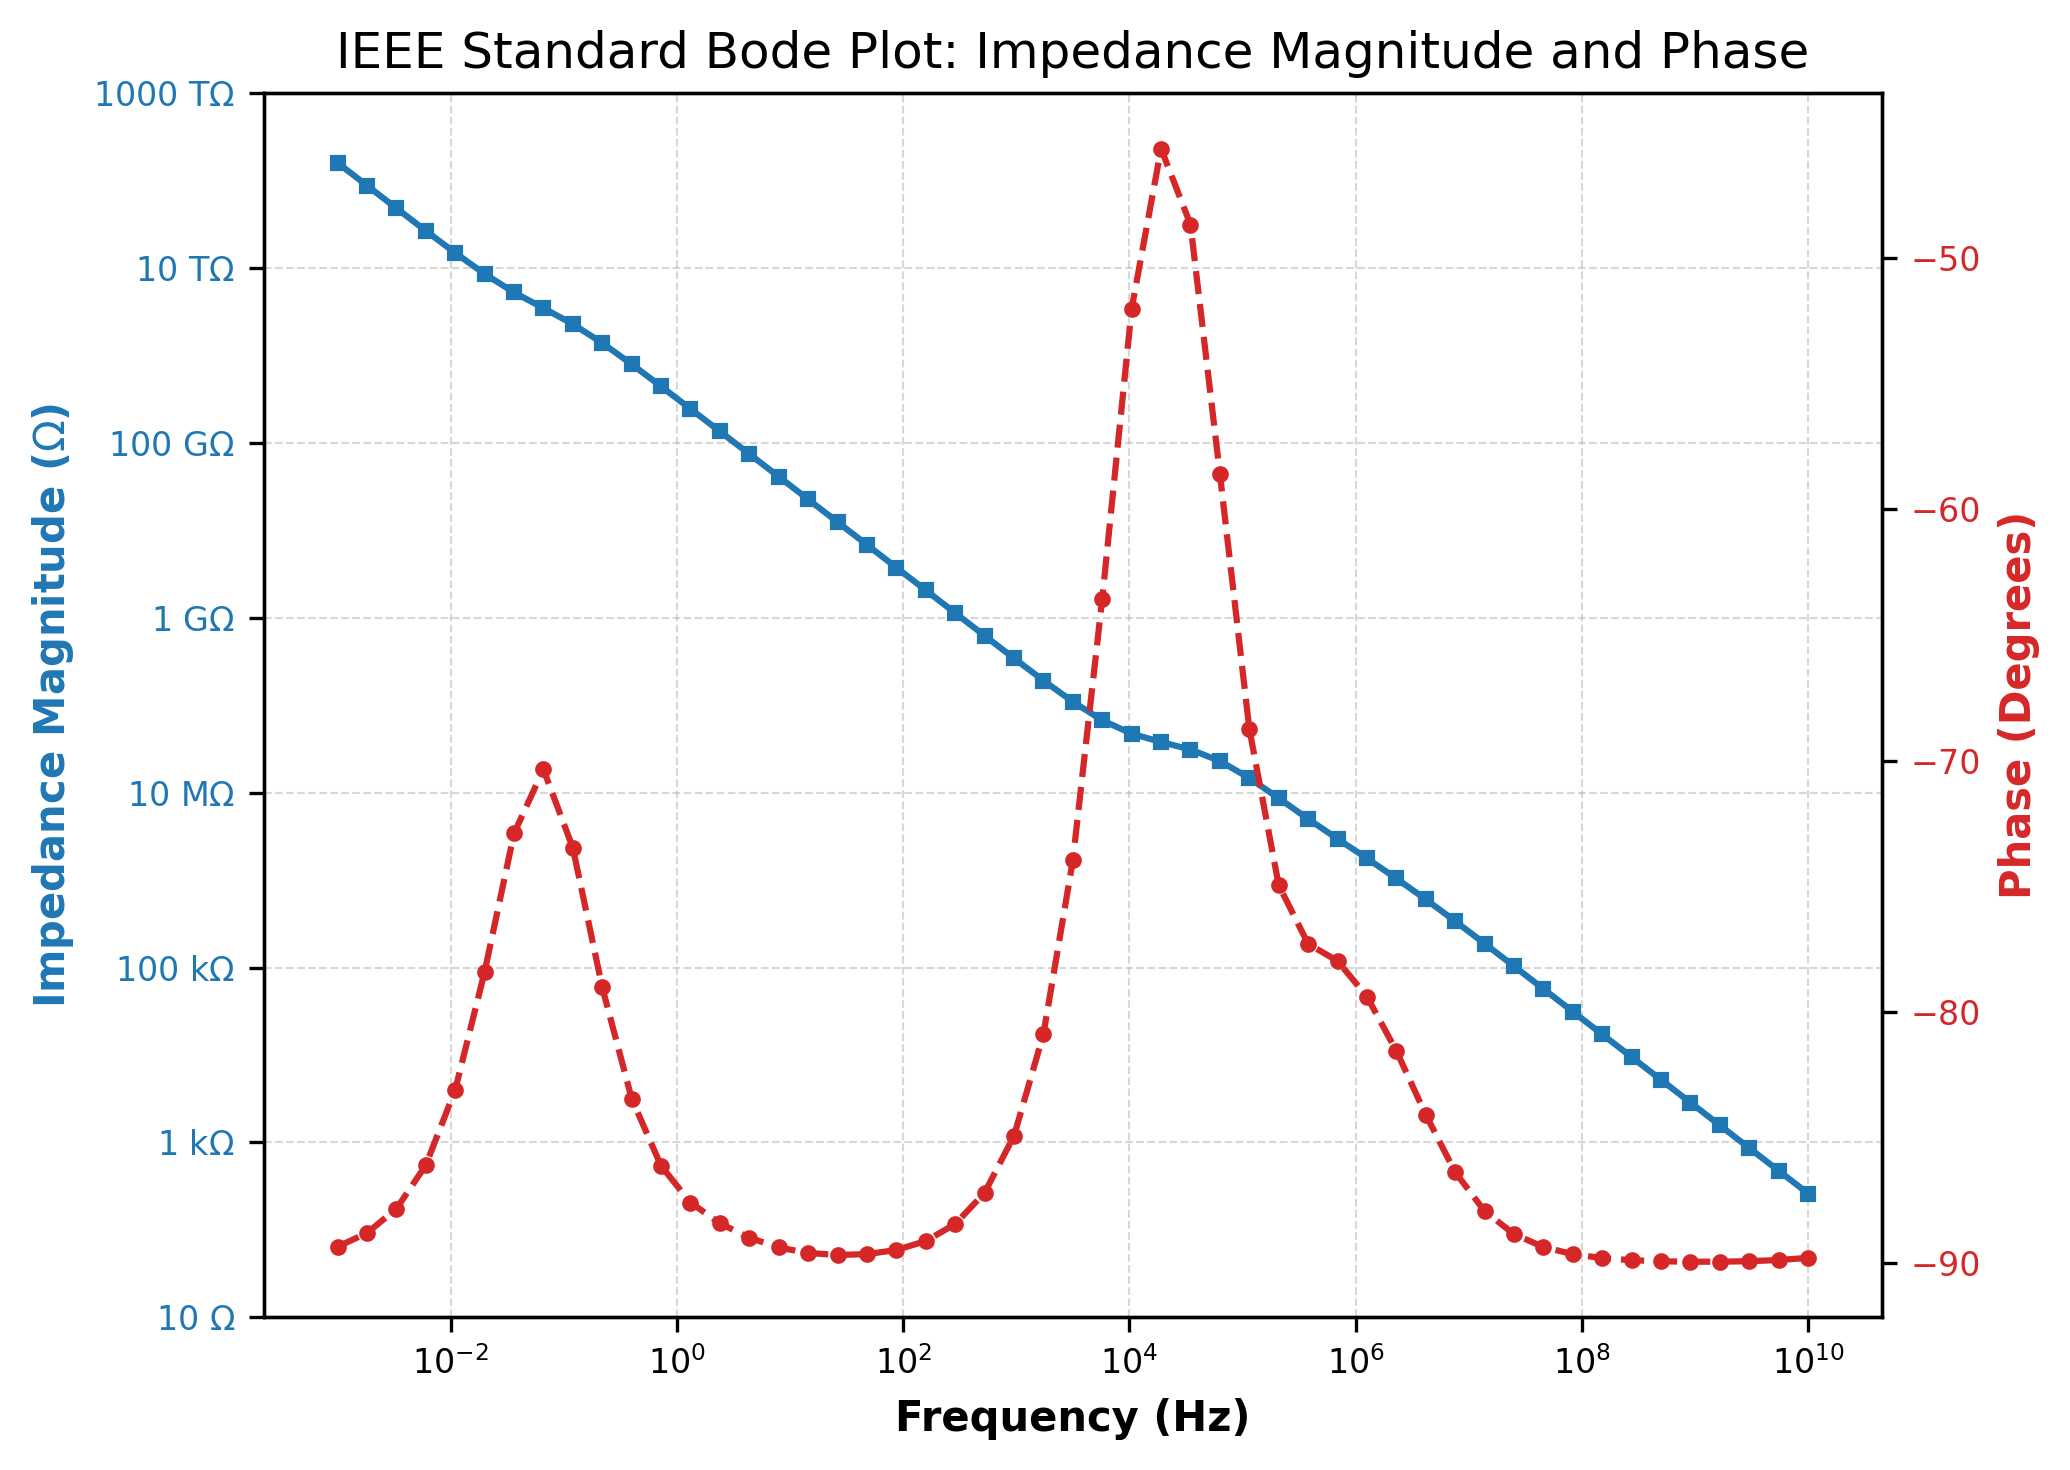

Bode plot generated and saved as bode_plot_complex.png


In [15]:
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

# 1. Calculate magnitude and phase
# Magnitude |Z| = sqrt(Re^2 + Im^2)
# Phase theta = arctan2(Im, Re) in degrees
re = df['ZM 1 magOhms YRe']
im = df['ZM 1 magOhms YReImag']
freq = df['ZM 1 magOhms X']

magnitude = np.sqrt(re**2 + im**2)
phase = np.degrees(np.arctan2(im, re))

# 2. Configure IEEE global plotting parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'figure.dpi': 300,
    'axes.labelsize': 10,
    'font.size': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

# 3. Extended impedance formatter for kOhm to TOhm
def extended_impedance_formatter(x, pos):
    if x >= 1e12: return f'{x/1e12:g} T$\Omega$'
    elif x >= 1e9: return f'{x/1e9:g} G$\Omega$'
    elif x >= 1e6: return f'{x/1e6:g} M$\Omega$'
    elif x >= 1e3: return f'{x/1e3:g} k$\Omega$'
    else: return f'{x:g} $\Omega$'

# 4. Create dual-axis plot
fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot Magnitude on ax1 (log-log)
ax1.loglog(freq, magnitude, color='#1f77b4', linestyle='-', marker='s', markersize=3, label='Magnitude $|Z|$')
ax1.set_xlabel('Frequency (Hz)', fontweight='bold')
ax1.set_ylabel('Impedance Magnitude ($\\Omega$)', color='#1f77b4', fontweight='bold')
ax1.set_ylim(1e1, 1e15)
ax1.yaxis.set_major_formatter(FuncFormatter(extended_impedance_formatter))
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

# Create second axis for Phase (semi-log)
ax2 = ax1.twinx()
ax2.semilogx(freq, phase, color='#d62728', linestyle='--', marker='o', markersize=3, label='Phase $\\theta$')
ax2.set_ylabel('Phase (Degrees)', color='#d62728', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title('IEEE Standard Bode Plot: Impedance Magnitude and Phase', fontsize=12)
fig.tight_layout()

# 5. Save and Show
plt.savefig('bode_plot_complex.png', dpi=300, bbox_inches='tight')
plt.show()

print('Bode plot generated and saved as bode_plot_complex.png')

# Task
# Plan:
* **Update Plotting Script for Complete Bode Representation**: Modify the visualization code to address the range issues in the low-frequency segment (mHz range). Specifically:
    1. Remove the hard-coded `ax1.set_ylim` limit to allow the Y-axis to auto-scale or cover a broader range (up to >100 TΩ as seen in the data).
    2. Refine the `extended_impedance_formatter` to ensure that extremely high impedance values (above 100 TΩ) display correctly with proper unit prefixes.
    3. Ensure the X-axis (Frequency) fully encompasses the range from 1 mHz ($10^{-3}$ Hz) to 1 MHz ($10^6$ Hz).
    4. Regenerate the dual-axis Bode plot (Magnitude and Phase) to include all data points from the dataset "/content/Zin.csv".
* **Final Summary**: Verify that the low-frequency impedance points (reaching $10^{14} \Omega$) are accurately represented and summarize the final visual parameters used for the high-quality academic output.

# Task:
Update the impedance visualization script for the data in "/content/Zin.csv" to correctly display the full range of complex impedance. Modify the `ax1.set_ylim` to accommodate the extremely high impedance values at low frequencies (mHz range, up to $159\text{ T}\Omega$) and update the `extended_impedance_formatter` to handle these magnitudes gracefully. Ensure the dual-axis plot (Magnitude in $\Omega$ on a log scale and Phase in Degrees on a linear scale) captures all points from $1\text{ mHz}$ to $1\text{ MHz}$. Finally, provide a summary of how the visual representation of the $100\text{ T}\Omega$+ range meets academic standards for impedance spectroscopy.

# Task
Update the impedance visualization script for the data in "/content/Zin.csv" to correctly display the full dynamic range of the complex impedance. Modify the `extended_impedance_formatter` function to use raw strings (e.g., `r'...'`) for all return values containing the LaTeX `\Omega` command to eliminate `SyntaxWarning` messages. Adjust the `ax1.set_ylim` upper limit to $10^{15}$ and ensure the X-axis (Frequency) starts from $10^{-3}$ Hz to fully capture the low-frequency magnitude points that reach approximately $159\text{ T}\Omega$. Generate the dual-axis Bode plot (Magnitude and Phase) according to IEEE standards and verify that the final output provides a clear, warning-free professional representation of the data.

<>:39: SyntaxWarning: invalid escape sequence '\O'
<>:39: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_12592/320126792.py:39: SyntaxWarning: invalid escape sequence '\O'
  ax1.set_ylabel('Impedance Magnitude ($\Omega$)', color='#1f77b4', fontweight='bold')


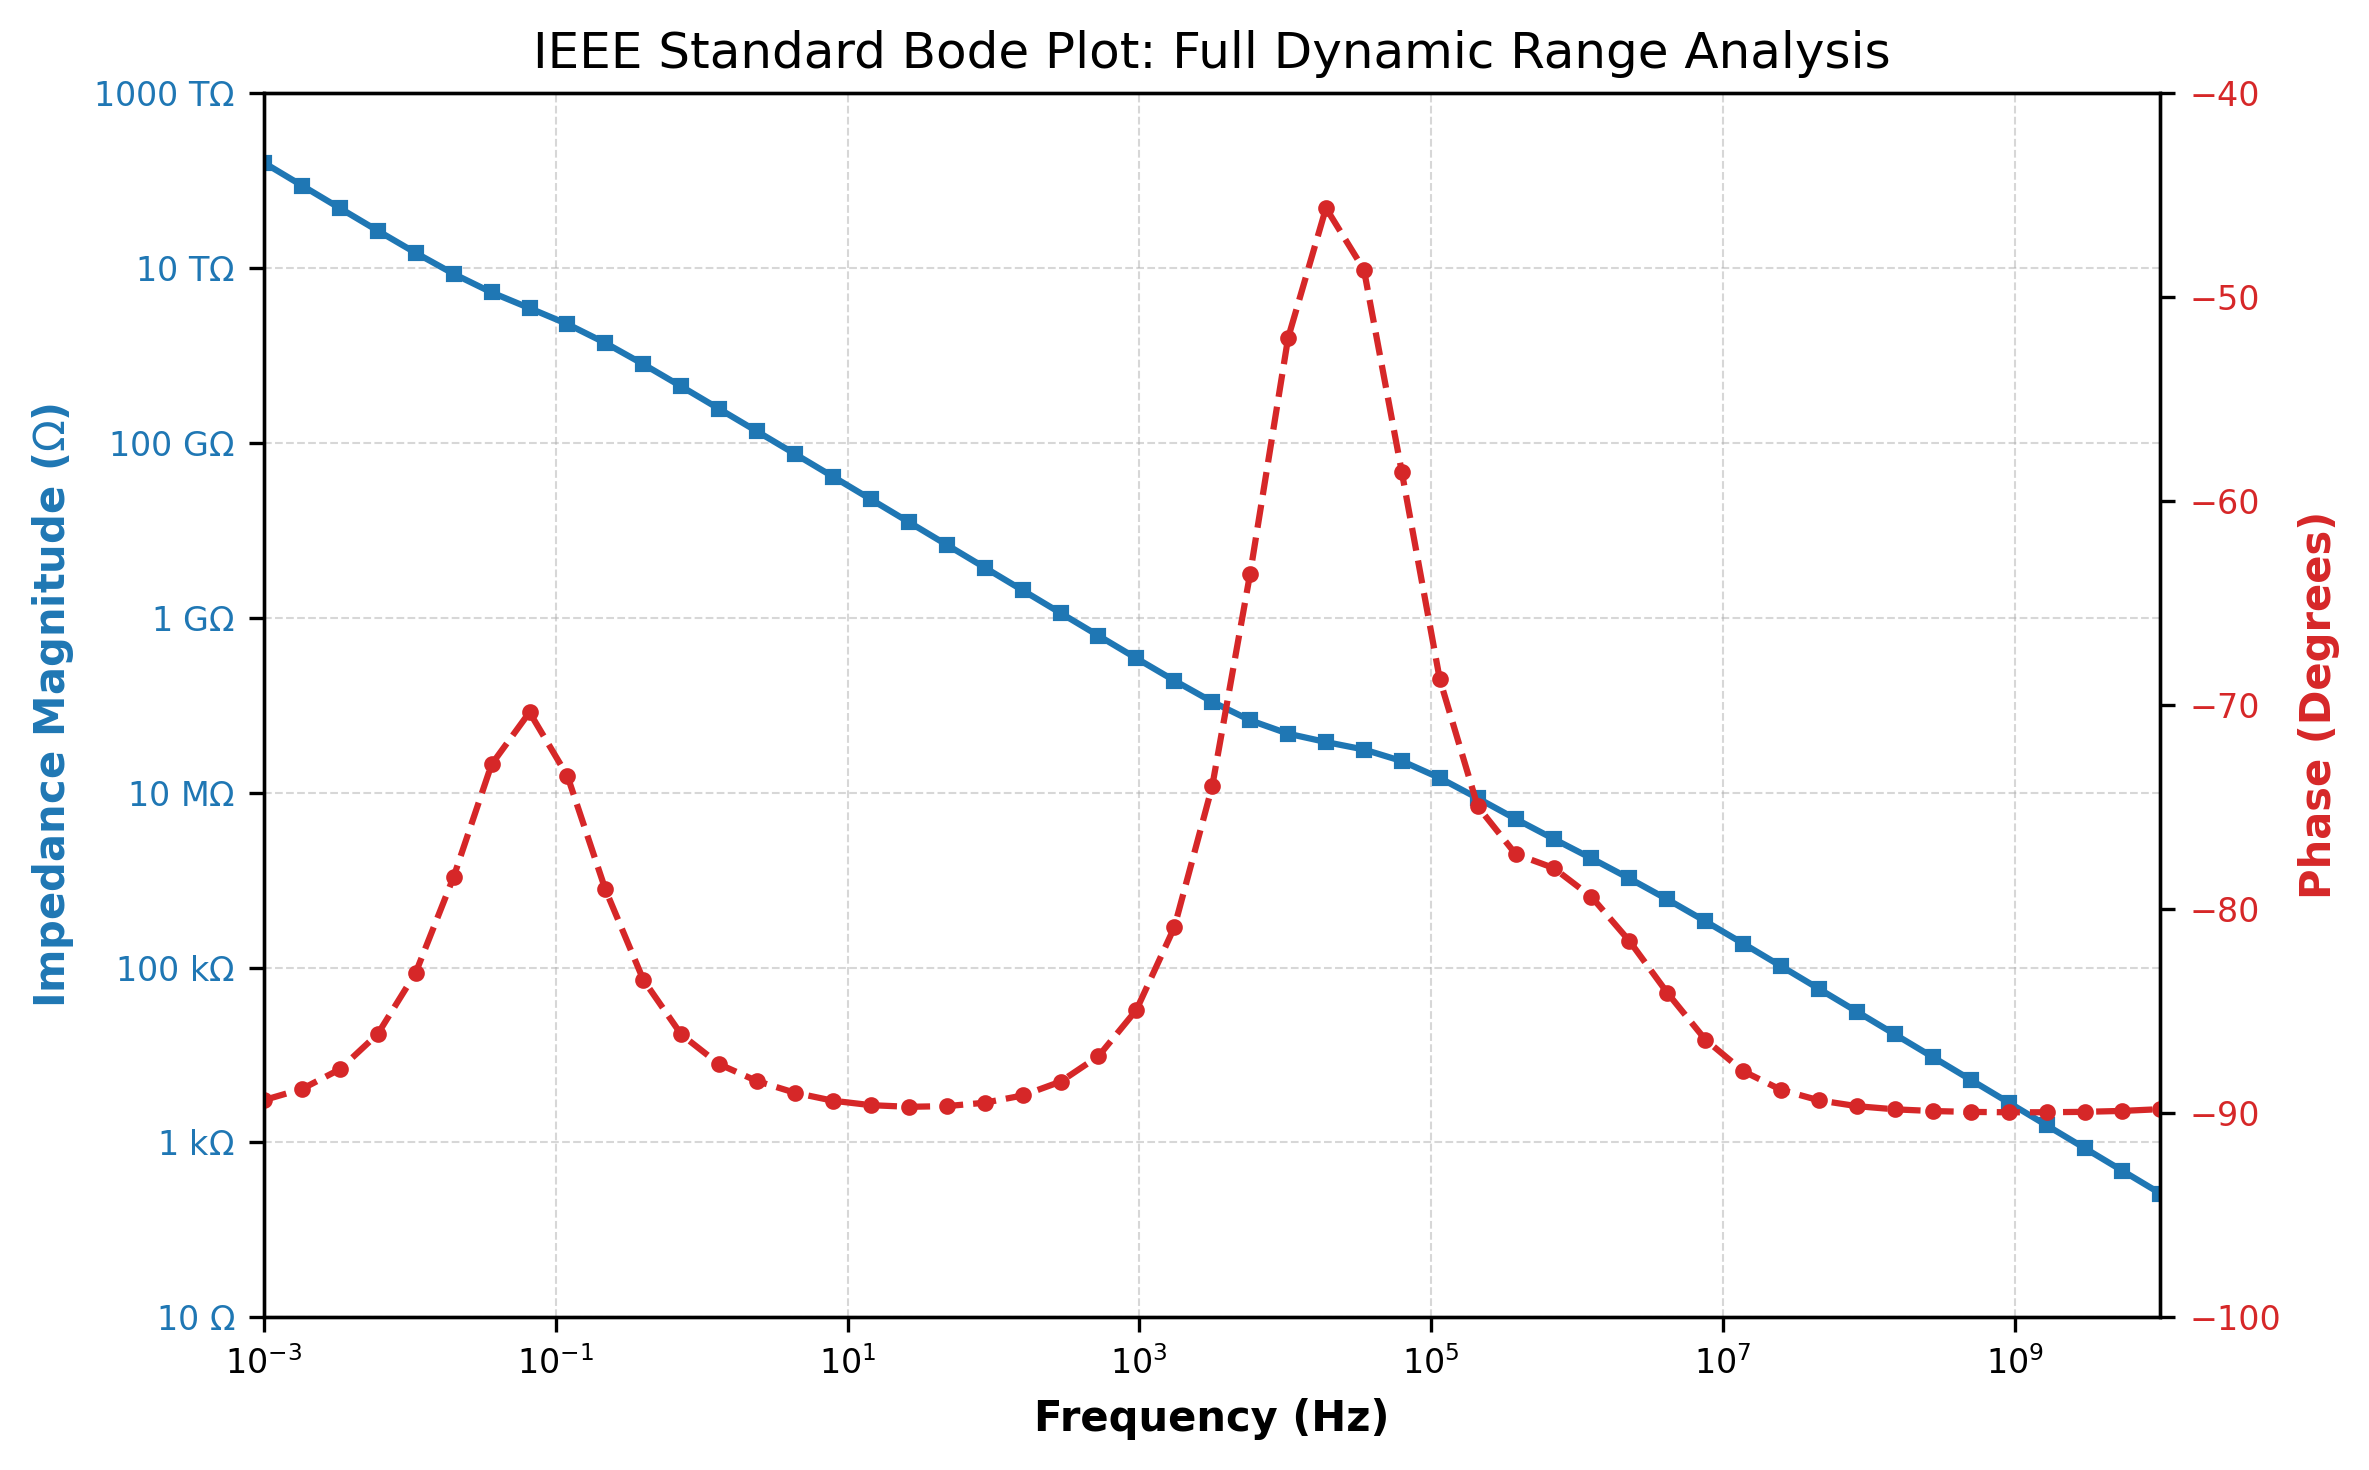

Final Bode plot generated and saved as bode_plot_final.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Recalculate magnitude and phase from the dataframe
re = df['ZM 1 magOhms YRe']
im = df['ZM 1 magOhms YReImag']
freq = df['ZM 1 magOhms X']

magnitude = np.sqrt(re**2 + im**2)
phase = np.degrees(np.arctan2(im, re))

# 2. Define the impedance formatter using raw strings to avoid SyntaxWarnings
def extended_impedance_formatter(x, pos):
    if x >= 1e12: return fr'{x/1e12:g} T$	{{\Omega}}$'
    elif x >= 1e9: return fr'{x/1e9:g} G$	{{\Omega}}$'
    elif x >= 1e6: return fr'{x/1e6:g} M$	{{\Omega}}$'
    elif x >= 1e3: return fr'{x/1e3:g} k$	{{\Omega}}$'
    else: return fr'{x:g} $	{{\Omega}}$'

# 3. Configure IEEE global plotting parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'figure.dpi': 300,
    'axes.labelsize': 10,
    'font.size': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

# 4. Create dual-axis plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Magnitude on ax1 (log-log)
ax1.loglog(freq, magnitude, color='#1f77b4', linestyle='-', marker='s', markersize=3, label='Magnitude $|Z|$')
ax1.set_xlabel('Frequency (Hz)', fontweight='bold')
ax1.set_ylabel('Impedance Magnitude ($\Omega$)', color='#1f77b4', fontweight='bold')

# Adjust limits to capture the mHz to MHz range and the ~160 T-Ohm peak
ax1.set_xlim(1e-3, 1e10)
ax1.set_ylim(1e1, 1e15)

# Apply the custom formatter
ax1.yaxis.set_major_formatter(FuncFormatter(extended_impedance_formatter))
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

# Create second axis for Phase (semi-log)
ax2 = ax1.twinx()
ax2.semilogx(freq, phase, color='#d62728', linestyle='--', marker='o', markersize=3, label='Phase $\theta$')
ax2.set_ylabel('Phase (Degrees)', color='#d62728', fontweight='bold')
ax2.set_ylim(-100, -40)
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title('IEEE Standard Bode Plot: Full Dynamic Range Analysis', fontsize=12)
fig.tight_layout()

# 5. Save and Show
plt.savefig('bode_plot_final.png', dpi=300, bbox_inches='tight')
plt.show()

print('Final Bode plot generated and saved as bode_plot_final.png')